In [2]:
import pandas as pd 
import numpy  as np  
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder 

In [3]:
df=pd.read_csv("city_day.csv")#dataset Loading 

In [4]:
df.head()

,City,Datetime,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Delhi,2015-01-01,153.3,241.7,182.9,33.0,81.3,38.5,1.87,64.5,83.6,18.93,20.81,8.32,204.5,Severe
1,Mumbai,2015-01-01,70.5,312.7,195.0,42.0,122.5,31.5,7.22,83.8,108.0,2.01,19.41,2.86,60.9,Satisfactory
2,Chennai,2015-01-01,174.1,275.4,56.2,68.8,230.9,28.5,8.56,60.8,43.9,19.07,10.19,9.63,486.5,Severe
3,Kolkata,2015-01-01,477.2,543.9,14.1,76.4,225.9,45.6,2.41,42.1,171.1,9.31,11.65,9.39,174.4,Very Poor
4,Bangalore,2015-01-01,171.6,117.7,123.3,12.4,61.9,49.7,1.26,79.7,164.3,6.04,12.74,9.59,489.7,Good


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 18265 entries, 0 to 18264
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        18265 non-null  str    
 1   Datetime    18265 non-null  str    
 2   PM2.5       18265 non-null  float64
 3   PM10        18265 non-null  float64
 4   NO          18265 non-null  float64
 5   NO2         18265 non-null  float64
 6   NOx         18265 non-null  float64
 7   NH3         18265 non-null  float64
 8   CO          18265 non-null  float64
 9   SO2         18265 non-null  float64
 10  O3          18265 non-null  float64
 11  Benzene     18265 non-null  float64
 12  Toluene     18265 non-null  float64
 13  Xylene      18265 non-null  float64
 14  AQI         18265 non-null  float64
 15  AQI_Bucket  18265 non-null  str    
dtypes: float64(13), str(3)
memory usage: 2.2 MB


In [6]:
df.describe()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI
count,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000,18265.000000
mean,250.597695,299.442491,100.481035,75.415916,125.964079,25.065042,5.002451,49.835839,100.406740,10.070033,15.063365,4.996341,251.111382
std,144.460292,173.479906,57.774795,43.460066,72.403893,14.452019,2.889439,28.988739,57.591436,5.785282,8.619433,2.899152,144.502626
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,125.700000,150.100000,50.600000,37.700000,63.100000,12.600000,2.490000,24.400000,50.600000,5.080000,7.640000,2.510000,125.400000
50%,251.000000,300.300000,100.200000,76.000000,126.200000,25.300000,5.000000,49.900000,100.700000,10.080000,15.130000,4.960000,251.200000
75%,376.200000,450.000000,151.000000,113.200000,188.900000,37.600000,7.510000,75.100000,150.400000,15.110000,22.500000,7.530000,376.400000
max,499.900000,600.000000,200.000000,150.000000,250.000000,50.000000,10.000000,100.000000,200.000000,20.000000,30.000000,10.000000,500.000000


In [7]:
df.isna().sum()

City          0
Datetime      0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

In [8]:
print("duplicate row:",df.duplicated().sum())#checking if duplicates are present or not

duplicate row: 0


In [9]:
df.drop(["Datetime", "City"], axis=1, inplace=True)

In [10]:
df.isna().sum()

PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
Xylene        0
AQI           0
AQI_Bucket    0
dtype: int64

In [11]:
def categorize_aqi(AQI):

    if AQI <= 50:
        return "Good"

    elif AQI <= 100:
        return "Satisfactory"

    elif AQI <= 200:
        return "Moderate"

    elif AQI <= 300:
        return "Poor"

    elif AQI <= 400:
        return "Very Poor"

    else:
        return "Severe"

df["AQI_Bucket"] = df["AQI"].apply(categorize_aqi)

In [12]:
x=df.drop("AQI_Bucket",axis=1)
y=df["AQI_Bucket"]

In [13]:
print(y)

0                Poor
1        Satisfactory
2              Severe
3            Moderate
4              Severe
             ...     
18260    Satisfactory
18261       Very Poor
18262       Very Poor
18263       Very Poor
18264       Very Poor
Name: AQI_Bucket, Length: 18265, dtype: str


In [14]:
encoder=LabelEncoder()
y=encoder.fit_transform(y)


In [15]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)


In [16]:
from sklearn.ensemble import RandomForestClassifier
rf_model=RandomForestClassifier( 
    n_estimators=200,
    random_state=42
)

In [17]:
rf_model.fit(x_train,y_train)
y_pred=rf_model.predict(x_test)

In [18]:
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


In [19]:
accuracy=accuracy_score(y_test,y_pred)
print(accuracy)

0.9994525047905831


In [20]:
report=classification_report(y_test,y_pred)
print("clasification report:",report)

clasification report:               precision    recall  f1-score   support

           0       1.00      1.00      1.00       363
           1       1.00      1.00      1.00       732
           2       1.00      1.00      1.00       760
           3       1.00      1.00      1.00       364
           4       1.00      1.00      1.00       731
           5       1.00      1.00      1.00       703

    accuracy                           1.00      3653
   macro avg       1.00      1.00      1.00      3653
weighted avg       1.00      1.00      1.00      3653



In [21]:


cm = confusion_matrix(y_test,y_pred)

print(cm)

[[362   0   0   1   0   0]
 [  0 732   0   0   0   0]
 [  0   0 760   0   0   0]
 [  1   0   0 363   0   0]
 [  0   0   0   0 731   0]
 [  0   0   0   0   0 703]]


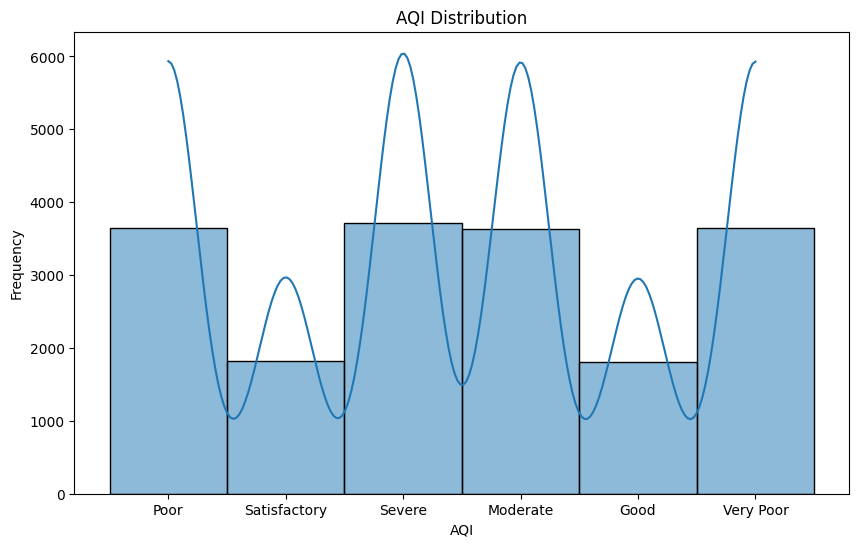

In [22]:
#histplot for AQI_Bucket(y)
plt.figure(figsize=(10,6))

sns.histplot(df["AQI_Bucket"], kde=True)

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

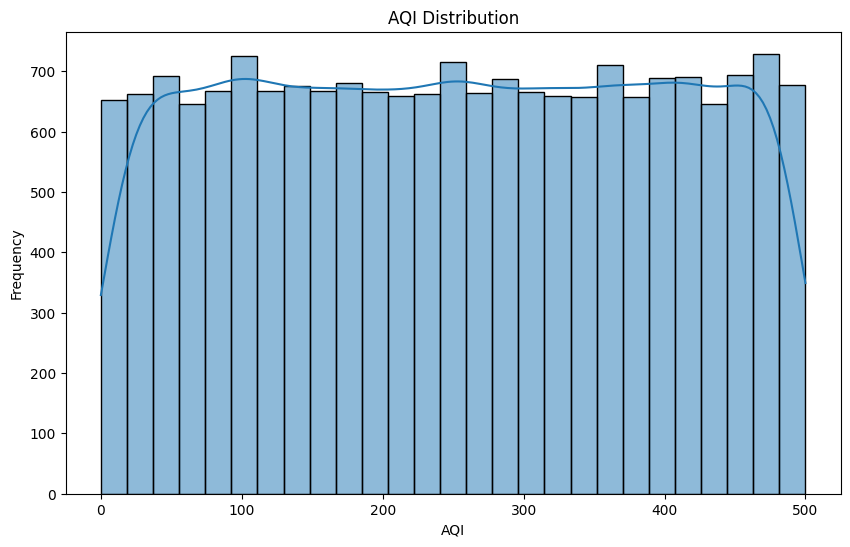

In [23]:
#histplot for AQI
plt.figure(figsize=(10,6))

sns.histplot(df["AQI"], kde=True)

plt.title("AQI Distribution")
plt.xlabel("AQI")
plt.ylabel("Frequency")

plt.show()

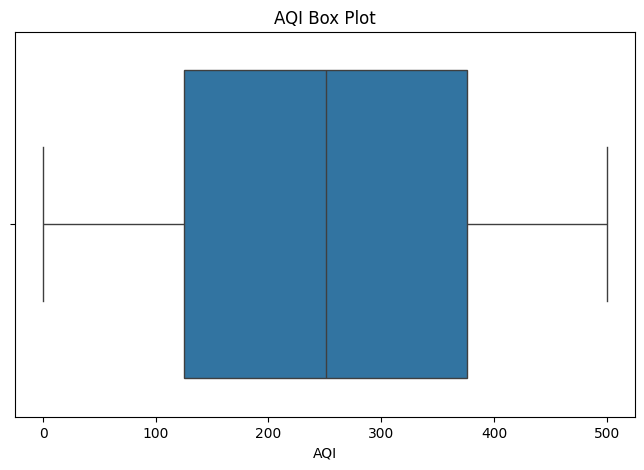

In [24]:
#boxplot for AQI
plt.figure(figsize=(8,5))

sns.boxplot(x=df["AQI"])

plt.title("AQI Box Plot")

plt.show()

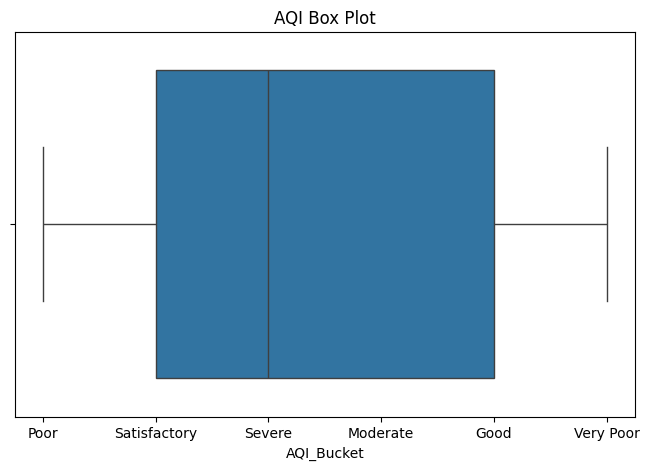

In [25]:
#box plot fro AQI_Bucket(y)
plt.figure(figsize=(8,5))

sns.boxplot(x=df["AQI_Bucket"])

plt.title("AQI Box Plot")

plt.show()

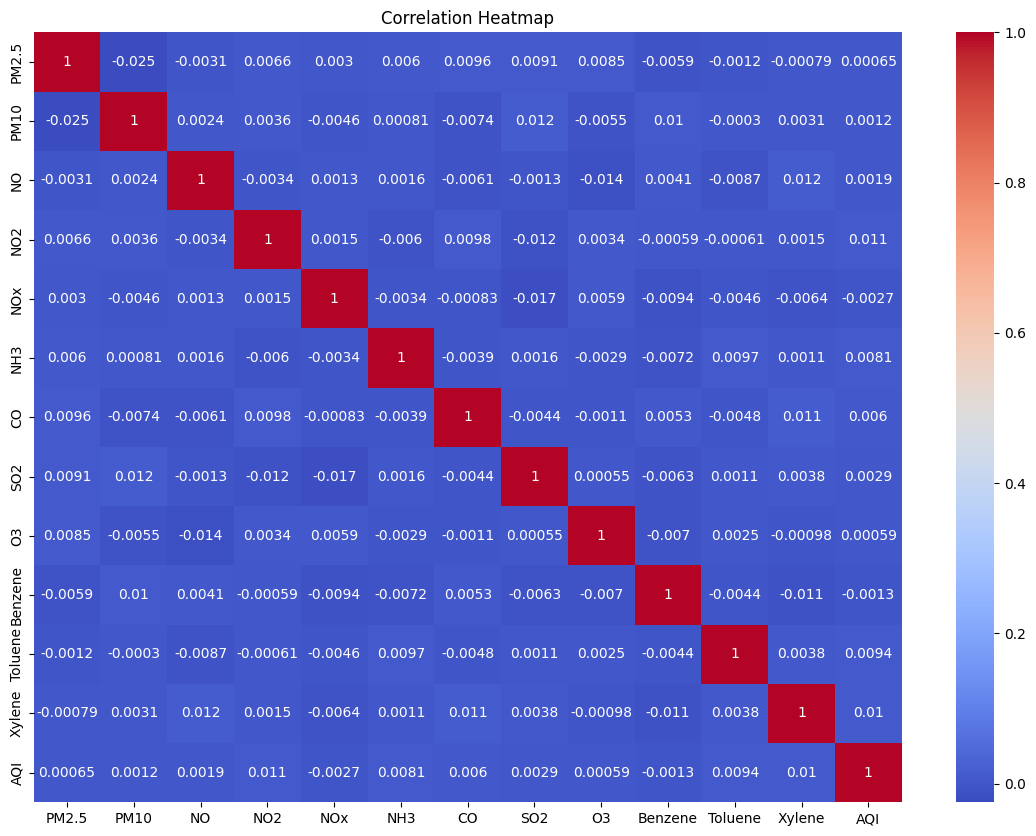

In [26]:
#Correlation Heatmap
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [27]:
pollutants = [
    "PM2.5",
    "PM10",
    "NO",
    "NO2",
    "NOx",
    "NH3",
    "CO",
    "SO2",
    "O3"
]

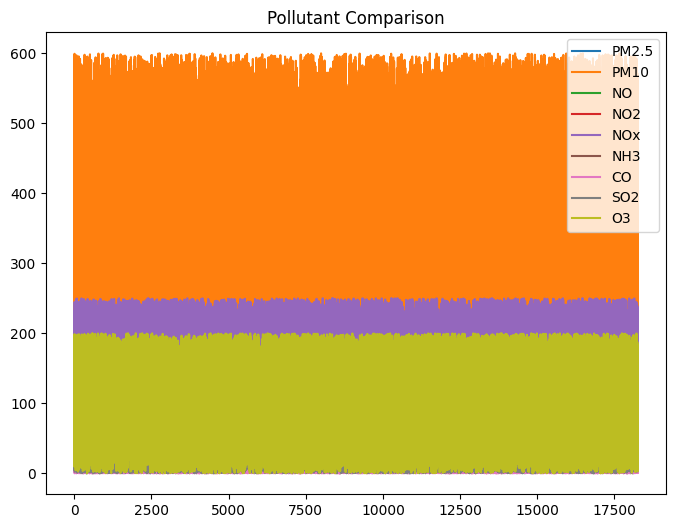

In [28]:
plt.figure(figsize=(8,6))

for pollutant in pollutants:

    plt.plot(
        df[pollutant],
        label=pollutant
    )

plt.legend()

plt.title("Pollutant Comparison")

plt.show()

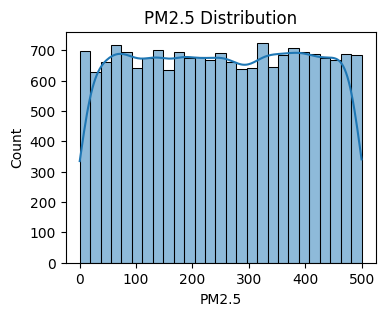

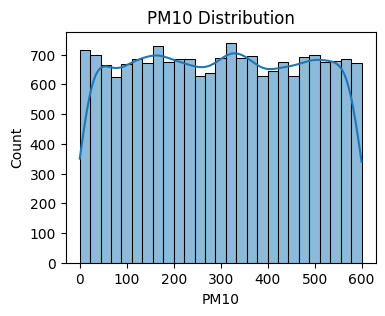

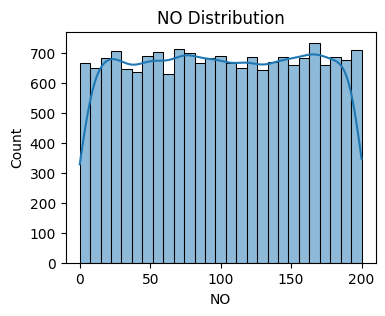

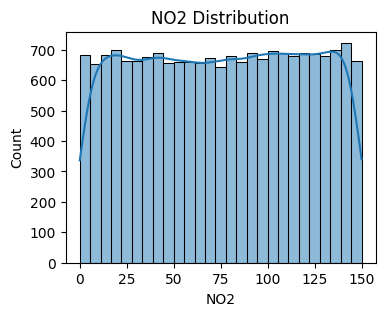

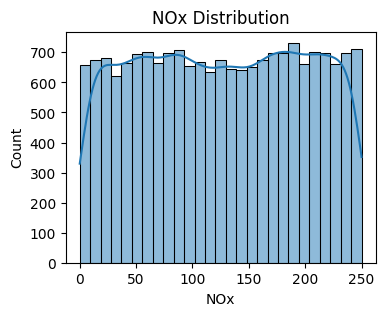

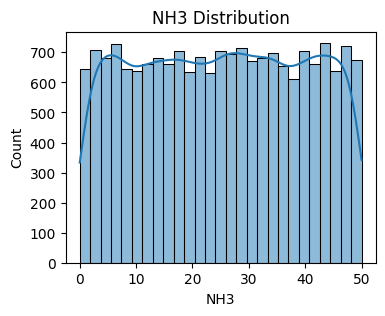

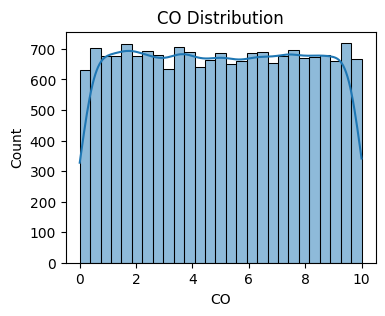

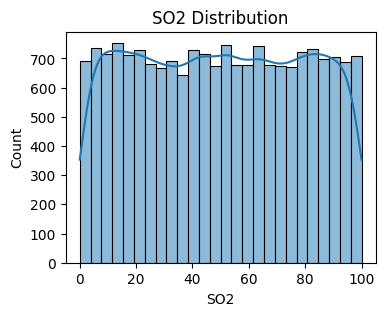

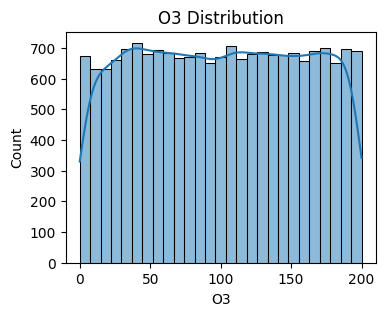

In [29]:
#histogram  for pollutants 
for pollutant in pollutants:

    plt.figure(figsize=(4,3))

    sns.histplot(
        df[pollutant],
        kde=True
    )

    plt.title(f"{pollutant} Distribution")

    plt.show()

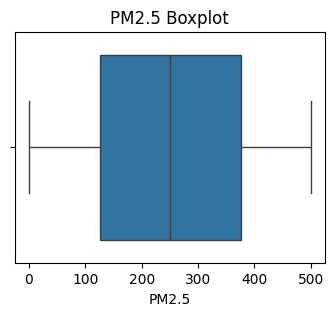

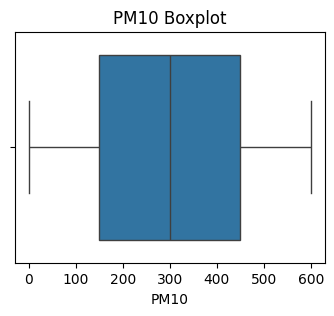

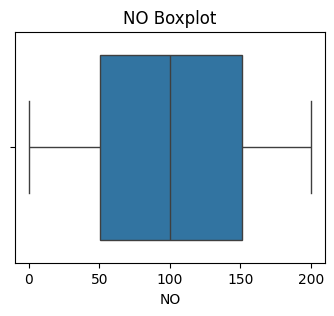

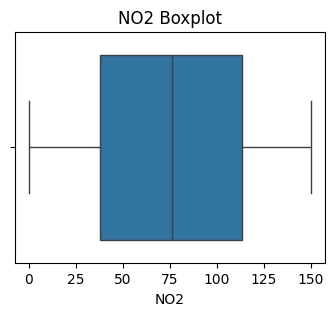

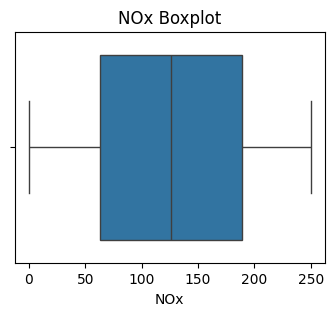

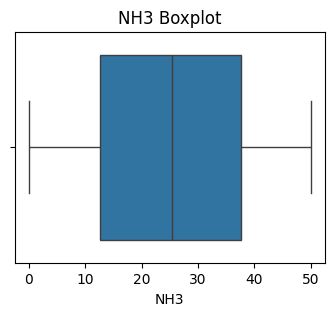

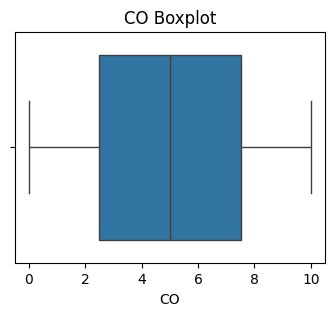

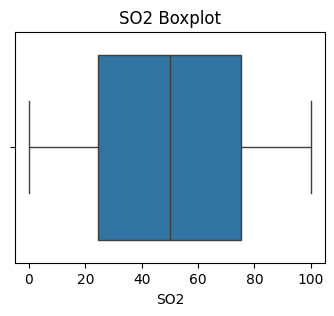

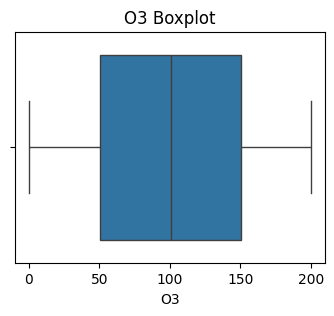

In [30]:
#boxplot for pollutants
for pollutant in pollutants:

    plt.figure(figsize=(4,3))

    sns.boxplot(
        x=df[pollutant]
    )

    plt.title(f"{pollutant} Boxplot")

    plt.show()

In [31]:
# AQI Formula For each pollutant:

# Ip=Ihi-Ilo/Bhi-Blo(Cp-Blo)+Ilo

# Symbol	Meaning
# Ip	AQI sub-index
# Cp	Pollutant concentration
# BHI	Upper breakpoint
# BLO	Lower breakpoint
# IHI	Upper AQI index
# ILO	Lower AQI index



In [32]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(y)

In [34]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Scaling
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

# Create model
knn = KNeighborsClassifier(
    n_neighbors=5
)

# Train model
knn.fit(x_train_scaled, y_train)

# Prediction
y_pred = knn.predict(x_test_scaled)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("KNN Accuracy:", accuracy)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

KNN Accuracy: 0.5086230495483165
              precision    recall  f1-score   support

           0       0.51      0.50      0.50       363
           1       0.43      0.61      0.51       732
           2       0.47      0.47      0.47       760
           3       0.35      0.17      0.23       364
           4       0.71      0.73      0.72       731
           5       0.49      0.39      0.43       703

    accuracy                           0.51      3653
   macro avg       0.49      0.48      0.48      3653
weighted avg       0.50      0.51      0.50      3653

[[180 117   3  63   0   0]
 [ 68 446 158  47   0  13]
 [  5 261 360   7  19 108]
 [103 184  15  62   0   0]
 [  0   0  26   0 535 170]
 [  0  23 207   0 198 275]]


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Create model
dt = DecisionTreeClassifier(
    max_depth=10,
    random_state=42
)

# Train model
dt.fit(x_train, y_train)

# Prediction
y_pred = dt.predict(x_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Decision Tree Accuracy:", accuracy)

# Classification Report
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

Decision Tree Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       363
           1       1.00      1.00      1.00       732
           2       1.00      1.00      1.00       760
           3       1.00      1.00      1.00       364
           4       1.00      1.00      1.00       731
           5       1.00      1.00      1.00       703

    accuracy                           1.00      3653
   macro avg       1.00      1.00      1.00      3653
weighted avg       1.00      1.00      1.00      3653

[[363   0   0   0   0   0]
 [  0 732   0   0   0   0]
 [  0   0 760   0   0   0]
 [  0   0   0 364   0   0]
 [  0   0   0   0 731   0]
 [  0   0   0   0   0 703]]


In [39]:
print("KNN Accuracy:", knn.score(x_test_scaled, y_test))

print("Decision Tree Accuracy:", dt.score(x_test, y_test))

KNN Accuracy: 0.5086230495483165
Decision Tree Accuracy: 1.0
